# Gaussian Process Regression: Package Comparison

Compares GP implementations across three packages on a 1D test problem:
- **scikit-learn** — simple baseline, no dependencies beyond sklearn
- **GPy** — mature library with rich kernel library
- **GPyTorch** — modern, GPU-capable, built on PyTorch

Test function: `f(x) = sin(2πx) + 0.3·sin(4πx)` with Gaussian noise

In [1]:
# Install if needed (comment out if already installed)
# !pip install scikit-learn GPy gpytorch torch matplotlib numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.gridspec import GridSpec

rng = np.random.default_rng(42)

# ── Test problem ──────────────────────────────────────────────────────────────
def true_f(x):
    return np.sin(2 * np.pi * x) + 0.3 * np.sin(4 * np.pi * x)

NOISE_STD = 0.15
N_TRAIN   = 20
N_TEST    = 300

X_train = np.sort(rng.uniform(0, 1, N_TRAIN))
y_train = true_f(X_train) + rng.normal(0, NOISE_STD, N_TRAIN)

X_test  = np.linspace(0, 1, N_TEST)
y_true  = true_f(X_test)

print(f"Training points: {N_TRAIN}   Test points: {N_TEST}   Noise σ: {NOISE_STD}")

Training points: 20   Test points: 300   Noise σ: 0.15


## Utility: shared plotting helper

In [3]:
def plot_gp(ax, X_test, mu, sigma, X_train, y_train, y_true, title, color):
    ax.plot(X_test, y_true, 'k--', lw=1.5, label='True f(x)', alpha=0.7)
    ax.scatter(X_train, y_train, c='k', s=30, zorder=5, label='Training data')
    ax.plot(X_test, mu, color=color, lw=2, label='GP mean')
    ax.fill_between(X_test, mu - 2*sigma, mu + 2*sigma,
                    alpha=0.25, color=color, label='±2σ')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

results = {}  # store (mu, sigma, rmse, fit_time) per package

---
## 1. scikit-learn `GaussianProcessRegressor`

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern

# Kernel: Matérn-5/2 + white noise  (length_scale and noise bounds guide optimiser)
kernel_sk = Matern(length_scale=0.2, nu=2.5, length_scale_bounds=(1e-2, 1.0)) \
          + WhiteKernel(noise_level=NOISE_STD**2, noise_level_bounds=(1e-5, 1e-1))

gpr_sk = GaussianProcessRegressor(
    kernel=kernel_sk,
    n_restarts_optimizer=5,
    normalize_y=True,
    random_state=42,
)

t0 = time.perf_counter()
gpr_sk.fit(X_train[:, None], y_train)
sk_time = time.perf_counter() - t0

mu_sk, sigma_sk = gpr_sk.predict(X_test[:, None], return_std=True)

rmse_sk = np.sqrt(np.mean((mu_sk - y_true)**2))
results['sklearn'] = (mu_sk, sigma_sk, rmse_sk, sk_time)

print(f"Optimised kernel : {gpr_sk.kernel_}")
print(f"RMSE : {rmse_sk:.4f}   Fit time: {sk_time*1000:.1f} ms")

Optimised kernel : Matern(length_scale=0.198, nu=2.5) + WhiteKernel(noise_level=0.0287)
RMSE : 0.0609   Fit time: 25.3 ms


---
## 2. GPy

In [5]:
try:
    import GPy

    # Matérn-5/2 kernel
    kernel_gpy = GPy.kern.Matern52(input_dim=1, variance=1.0, lengthscale=0.2)

    model_gpy = GPy.models.GPRegression(
        X_train[:, None],
        y_train[:, None],
        kernel_gpy
    )
    model_gpy.Gaussian_noise.variance = NOISE_STD**2

    t0 = time.perf_counter()
    model_gpy.optimize_restarts(num_restarts=5, verbose=False, messages=False)
    gpy_time = time.perf_counter() - t0

    mu_gpy, var_gpy = model_gpy.predict(X_test[:, None])
    mu_gpy   = mu_gpy.ravel()
    sigma_gpy = np.sqrt(var_gpy.ravel())

    rmse_gpy = np.sqrt(np.mean((mu_gpy - y_true)**2))
    results['GPy'] = (mu_gpy, sigma_gpy, rmse_gpy, gpy_time)

    print(model_gpy)
    print(f"RMSE : {rmse_gpy:.4f}   Fit time: {gpy_time*1000:.1f} ms")

except ImportError:
    print("GPy not installed — skipping. Install with: pip install GPy")
    results['GPy'] = None


Name : GP regression
Objective : 2.1563465768796863
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                 value  |  constraints  |  priors
  Mat52.variance           |    0.5314682630070311  |      +ve      |        
  Mat52.lengthscale        |   0.19079866099227066  |      +ve      |        
  Gaussian_noise.variance  |  0.016227039494691276  |      +ve      |        
RMSE : 0.0635   Fit time: 86.8 ms


---
## 3. GPyTorch (exact GP)

Optimised: length_scale=0.191  outputscale=0.531  noise=0.0162
RMSE : 0.0635   Fit time: 417.4 ms


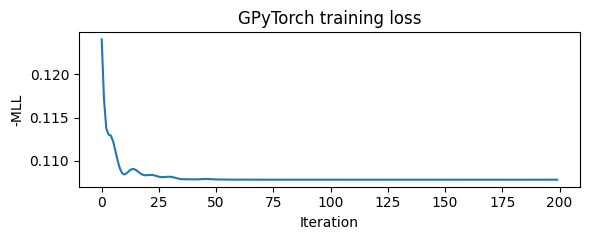

In [6]:
try:
    import torch
    import gpytorch

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    X_te = torch.tensor(X_test,  dtype=torch.float32)

    class ExactGPModel(gpytorch.models.ExactGP):
        def __init__(self, X, y, likelihood):
            super().__init__(X, y, likelihood)
            self.mean_module   = gpytorch.means.ZeroMean()
            self.covar_module  = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.MaternKernel(nu=2.5)
            )

        def forward(self, x):
            return gpytorch.distributions.MultivariateNormal(
                self.mean_module(x),
                self.covar_module(x)
            )

    likelihood_gpt = gpytorch.likelihoods.GaussianLikelihood()
    model_gpt      = ExactGPModel(X_tr, y_tr, likelihood_gpt)

    # Initialise hyperparameters close to truth
    model_gpt.covar_module.base_kernel.lengthscale = 0.2
    likelihood_gpt.noise                           = NOISE_STD**2

    model_gpt.train()
    likelihood_gpt.train()

    optimiser = torch.optim.Adam(model_gpt.parameters(), lr=0.05)
    mll       = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_gpt, model_gpt)

    N_ITER = 200
    t0 = time.perf_counter()
    losses = []
    for i in range(N_ITER):
        optimiser.zero_grad()
        loss = -mll(model_gpt(X_tr), y_tr)
        loss.backward()
        optimiser.step()
        losses.append(loss.item())
    gpt_time = time.perf_counter() - t0

    model_gpt.eval()
    likelihood_gpt.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood_gpt(model_gpt(X_te))

    mu_gpt    = pred.mean.numpy()
    sigma_gpt = pred.stddev.numpy()

    rmse_gpt = np.sqrt(np.mean((mu_gpt - y_true)**2))
    results['GPyTorch'] = (mu_gpt, sigma_gpt, rmse_gpt, gpt_time)

    ls  = model_gpt.covar_module.base_kernel.lengthscale.item()
    var = model_gpt.covar_module.outputscale.item()
    nz  = likelihood_gpt.noise.item()
    print(f"Optimised: length_scale={ls:.3f}  outputscale={var:.3f}  noise={nz:.4f}")
    print(f"RMSE : {rmse_gpt:.4f}   Fit time: {gpt_time*1000:.1f} ms")

    # Quick loss curve
    plt.figure(figsize=(6, 2.5))
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('-MLL')
    plt.title('GPyTorch training loss')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("gpytorch / torch not installed — skipping. Install with: pip install gpytorch torch")
    results['GPyTorch'] = None

---
## 4. Side-by-side comparison

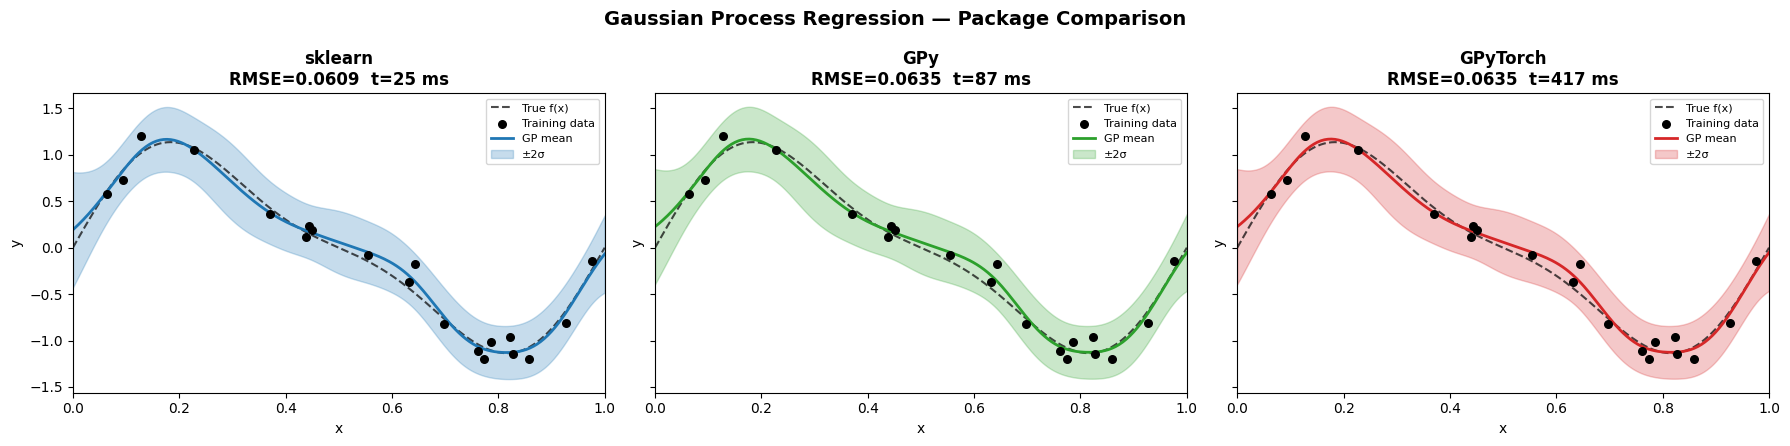

Saved gp_comparison.png


In [7]:
available = {k: v for k, v in results.items() if v is not None}
colors = {'sklearn': '#1f77b4', 'GPy': '#2ca02c', 'GPyTorch': '#d62728'}

n = len(available)
fig, axes = plt.subplots(1, n, figsize=(6*n, 4.5), sharey=True)
if n == 1:
    axes = [axes]

for ax, (name, (mu, sigma, rmse, t)) in zip(axes, available.items()):
    plot_gp(ax, X_test, mu, sigma, X_train, y_train, y_true,
            f"{name}\nRMSE={rmse:.4f}  t={t*1000:.0f} ms",
            colors.get(name, 'purple'))

fig.suptitle('Gaussian Process Regression — Package Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved gp_comparison.png")

---
## 5. Metrics summary

In [8]:
print(f"{'Package':<12} {'RMSE':>8} {'Fit time':>12} {'NLL (test)':>12}")
print('-' * 48)

for name, val in available.items():
    mu, sigma, rmse, t = val
    # Gaussian NLL on test set
    nll = 0.5 * np.mean(((y_true - mu) / sigma)**2 + np.log(2*np.pi*sigma**2))
    print(f"{name:<12} {rmse:>8.4f} {t*1000:>10.1f} ms {nll:>12.4f}")

Package          RMSE     Fit time   NLL (test)
------------------------------------------------
sklearn        0.0609       25.3 ms      -0.8147
GPy            0.0635       86.8 ms      -0.8156
GPyTorch       0.0635      417.4 ms      -0.8156


---
## 6. Uncertainty calibration plot

A well-calibrated GP should have ~95 % of true values inside its ±2σ band.

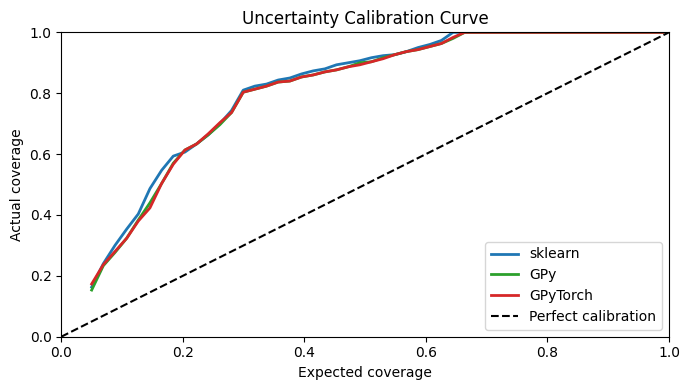

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

confidence_levels = np.linspace(0.05, 0.99, 50)

for name, val in available.items():
    mu, sigma, *_ = val
    coverage = [
        np.mean(np.abs(y_true - mu) <= z * sigma)
        for z in [c for c in np.percentile(
            np.abs(np.random.randn(10_000)), np.array(confidence_levels)*100
        )]
    ]
    ax.plot(confidence_levels, coverage, label=name, color=colors.get(name, 'purple'), lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Expected coverage')
ax.set_ylabel('Actual coverage')
ax.set_title('Uncertainty Calibration Curve')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('gp_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Notes

| Package | Strengths | Weaknesses |
|---------|-----------|------------|
| **scikit-learn** | Zero extra dependencies, clean API, stable | No GPU, limited kernel customisation, slow for N > 5 k |
| **GPy** | Rich kernel library, good diagnostics, BGPLVM | Slower development pace, no GPU |
| **GPyTorch** | GPU-ready, sparse/deep GPs, active development | Verbose API, requires PyTorch |

All three use Matérn-5/2 kernels here so differences reflect optimiser behaviour, not modelling power.